# Ch06_09 — PPO (Proximal Policy Optimization) + GAE — continuous control

PPO to dzisiaj jeden z najpopularniejszych algorytmów **on-policy** dla ciągłej kontroli,
bo jest:
- relatywnie prosty,
- stabilny,
- i dobrze skaluje się do większych sieci.

## Skąd się bierze PPO?

W A2C robimy policy gradient na advantage:

$
L^{PG}(\theta) = \mathbb{E}\big[\log \pi_\theta(a|s)\, \hat A\big]
$

Problem: jeśli w jednym update zbyt mocno zmienimy \(\pi_\theta\),
jakość może „odjechać”.

PPO używa „starej” polityki \(\pi_{\theta_{old}}\) i ratio:

$
r_t(\theta)=\frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}
$

oraz clipped objective:

$
L^{CLIP}(\theta)=\mathbb{E}\Big[\min\big(r_t(\theta)\hat A_t,\;\text{clip}(r_t(\theta),1-\epsilon,1+\epsilon)\hat A_t\big)\Big]
$

Do tego dochodzi:
- loss krytyka \( (V(s)-\text{return})^2\),
- bonus entropii (opcjonalnie),
- advantage liczone przez **GAE(λ)**.

---

## Środowiska

W klasie:
- **Pendulum-v1** (zawsze dostępne)
- **InvertedPendulum-v4** (MuJoCo — szybkie, dobre na demo)

Projekt / praca domowa:
- **Hopper-v4**
- **Walker2d-v4**
- **HalfCheetah-v4**

> MuJoCo wymaga instalacji: `pip install "gymnasium[mujoco]"`.


In [1]:
# !pip install gymnasium
# !pip install "gymnasium[mujoco]"  # jeśli chcesz MuJoCo

import numpy as np
import matplotlib.pyplot as plt
import torch

from policy_based_continuous import train_ppo


## Wybór środowiska

Jeśli MuJoCo nie jest zainstalowane, `InvertedPendulum-v4` rzuci błąd importu.
Wtedy na początek ustaw `env_id="Pendulum-v1"`.

Docelowo (projekt):
- Hopper-v4 / Walker2d-v4: zwykle 1–3 mln kroków, sensownie na domowe GPU/CPU,
- HalfCheetah-v4: często podobny rząd wielkości.


In [2]:
cfg = dict(
    env_id="InvertedPendulum-v4",   # zmień na "Pendulum-v1" jeśli nie masz MuJoCo
    seed=0,
    total_steps=200_000,            # na Pendulum możesz dać mniej; na Hopper więcej
    rollout_steps=2048,
    update_epochs=10,
    minibatch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    actor_lr=3e-4,
    critic_lr=1e-3,
    clip_coef=0.2,
    ent_coef=0.0,
    hidden_sizes=(64, 64),
    target_kl=0.01,                 # zabezpieczenie przed zbyt dużym update
)

try:
    ac, log = train_ppo(**cfg)
except ImportError as e:
    print(e)
    print("\nUstawiam env_id='Pendulum-v1' jako fallback i odpalam ponownie...\n")
    cfg["env_id"] = "Pendulum-v1"
    ac, log = train_ppo(**cfg)

log.steps[:3], log.avg_return[:3]


/home/piotr/anaconda3/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/piotr/anaconda3/lib/python3.8/site-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


([2048, 12288, 22528], [1.0, 1.0, 1.0])

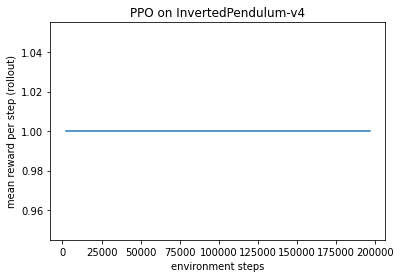

In [3]:
plt.figure()
plt.plot(log.steps, log.avg_return)
plt.xlabel("environment steps")
plt.ylabel("mean reward per step (rollout)")
plt.title(f"PPO on {cfg['env_id']}")
plt.show()


## Zadanie / projekt (Hopper / Walker2d / HalfCheetah)

1. Zmień `env_id` na jedno z:
   - `"Hopper-v4"`
   - `"Walker2d-v4"`
   - `"HalfCheetah-v4"`
2. Zwiększ `total_steps` (np. 1_000_000 – 3_000_000).
3. Strojenie, które zwykle pomaga:
   - większe sieci: `(256, 256)`
   - `ent_coef` małe dodatnie (np. 0.001)
   - `rollout_steps` większe (np. 4096) jeśli RAM pozwala
   - `target_kl` 0.01–0.03 (stabilność)

> Na zajęciach można pokazać krótki trening na InvertedPendulum,
> a cięższe środowiska zostawić jako projekt domowy.
